In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("predictive_maintenance_v3.csv")

In [3]:
df.sample(10)

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
6348,2024-01-05 12:52:02,6,Pump,1.89,49.38,NaN,126.1,1225.7,normal,29.63,15.3,46.90,0,none,0
14378,2024-01-14 19:18:36,12,Compressor,2.27,52.93,14.31,104.3,1694.3,normal,81.40,11.6,12.10,0,none,0
3182,2024-01-10 16:07:22,3,CNC,0.98,47.56,5.18,20.6,908.5,idle,33.83,9.3,60.78,0,none,0
22158,2024-01-06 11:47:19,19,Robotic Arm,NaN,52.28,7.95,57.0,506.9,peak,53.92,10.0,40.14,0,none,0
18465,2024-01-05 21:16:00,16,Robotic Arm,0.38,29.87,2.50,16.7,153.6,idle,475.45,15.2,0.50,0,none,0
1283,2024-01-02 03:14:00,2,CNC,0.83,43.86,5.37,24.6,885.4,idle,391.75,15.5,53.23,0,none,0
7816,2024-01-07 23:23:19,7,Pump,0.53,37.54,3.41,16.2,561.5,idle,3.42,9.3,67.90,0,none,0
19338,2024-01-01 19:39:00,17,Robotic Arm,1.80,42.04,NaN,47.9,345.8,normal,159.72,11.9,35.71,0,none,0
20851,2024-01-05 07:26:00,18,Robotic Arm,1.28,44.66,5.62,43.1,364.7,normal,310.16,10.0,0.50,0,none,0
2437,2024-01-02 01:08:00,3,CNC,0.91,47.03,4.92,23.1,880.4,idle,183.38,12.2,73.21,0,none,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  object 
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  object 
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  object 
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  object 
 14  estimated_repair_cost 

In [5]:
df.isnull().sum()

timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64

In [6]:
numF = df.select_dtypes(include = ['number']).columns.tolist()
toremove = ['rul_hours', 'failure_within_24h', 'estimated_repair_cost']
for col in toremove:
    if col in numF:
        numF.remove(col)


In [17]:
catF = df.select_dtypes(include = ['object']).columns.tolist()
catF.remove('failure_type')
print(catF)

['timestamp', 'machine_type', 'operating_mode']


In [ ]:
for col in numF:
    plt.figure(figsize = (8, 4))
    sns.histplot(df[col], kde = True)

In [8]:
df.describe()

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000


In [ ]:
# vibration_rms              1000
# temperature_motor           834
# current_phase_avg           731
# pressure_level              924
# rpm                         533

# vibMean = df.loc[df['vibration_rms'] != 0, 'vibration_rms'].mean().round(2)
# tempMean = df.loc[df['temperature_motor'] != 0, 'temperature_motor'].mean().round(2)
# currentMean = df.loc[df['current_phase_avg'] != 0, 'current_phase_avg'].mean().round(2)
# pressureMean = df.loc[df['pressure_level'] != 0, 'pressure_level'].mean().round(2)
# rpmMean = df.loc[df['rpm'] != 0, 'rpm'].mean().round(2)

# df['vibration_rms'] = df['vibration_rms'].replace(0, vibMean)
# df['temperature_motor'] = df['temperature_motor'].replace(0, tempMean)
# df['current_phase_avg'] = df['current_phase_avg'].replace(0, currentMean)
# df['pressure_level'] = df['pressure_level'].replace(0, pressureMean)
# df['rpm'] = df['rpm'].replace(0, rpmMean)

In [9]:
import pandas as pd

df = df.groupby("machine_type").apply(
    lambda group: group.fillna(group.mean(numeric_only=True))
)
df = df.reset_index(drop=True)
print(df.isnull().sum())

timestamp                  0
machine_id                 0
machine_type               0
vibration_rms              0
temperature_motor          0
current_phase_avg          0
pressure_level             0
rpm                        0
operating_mode             0
hours_since_maintenance    0
ambient_temp               0
rul_hours                  0
failure_within_24h         0
failure_type               0
estimated_repair_cost      0
dtype: int64


C:\Users\laksh\AppData\Local\Temp\ipykernel_28780\1114736700.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("machine_type").apply(


<Axes: xlabel='count', ylabel='failure_type'>

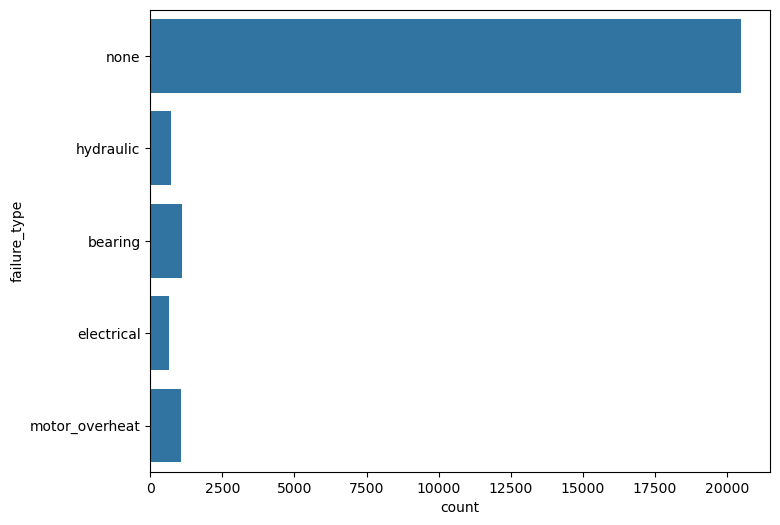

In [14]:
df['failure_type'].unique()
plt.figure(figsize = (8, 6))
sns.countplot(df['failure_type'])

<Axes: >

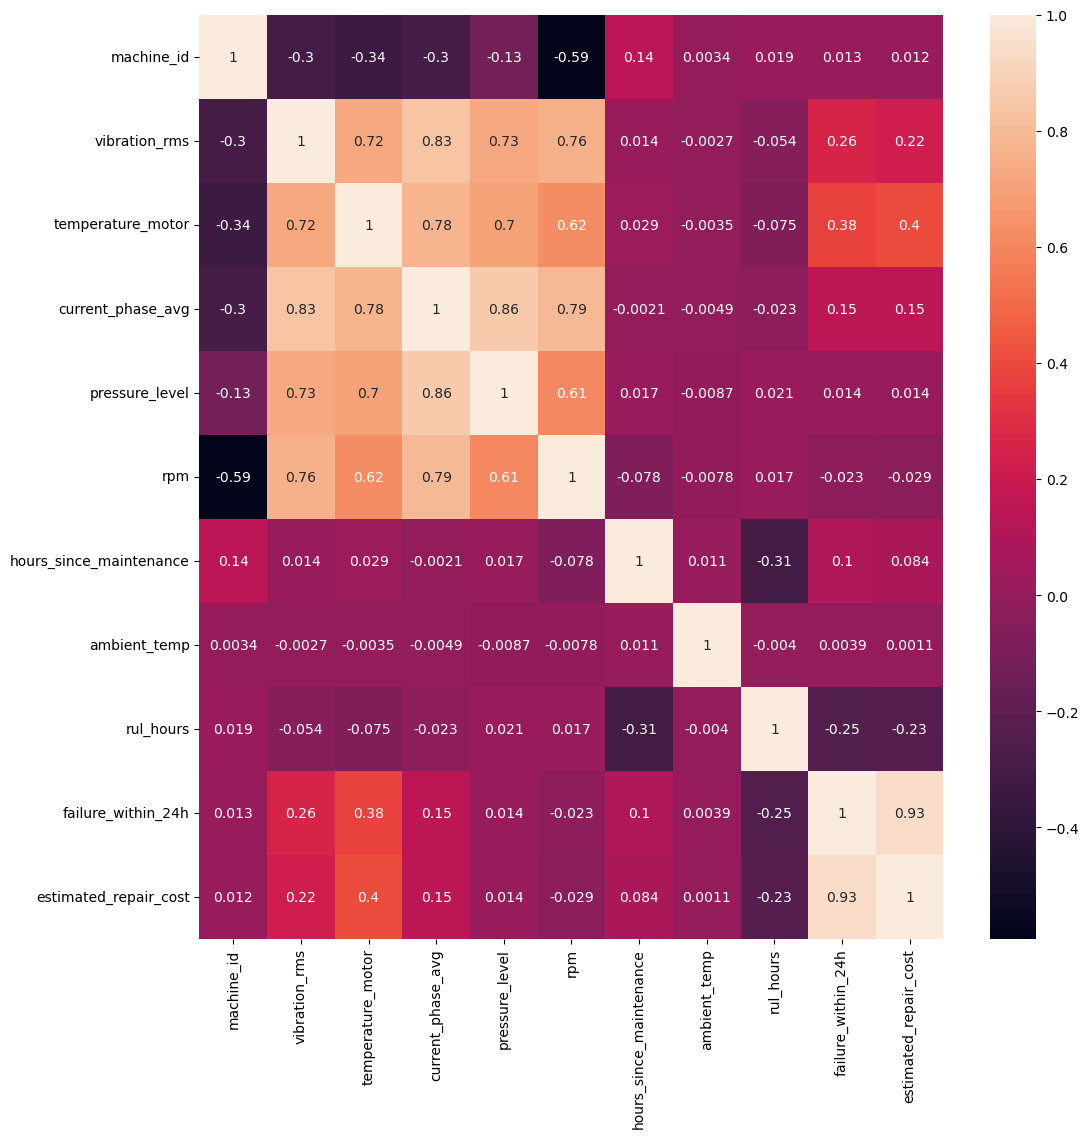

In [16]:
plt.figure(figsize = (12, 12))
sns.heatmap(df.corr(numeric_only = True), annot = True)

# vibration_rms # temperature_motor # current_phase_avg # hours_since_maintenance# pressure_level # machine_type # machine_id

In [18]:
from scipy.stats import chi2_contingency

# Function to calculate Cramer's V
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Compare categorical features against failure_type
features = ['machine_type', 'operating_mode']
results = {}

for f in features:
    results[f] = cramers_v(df[f], df['failure_type'])

print("Impact of categorical features on failure_type:")
for f, val in results.items():
    print(f"{f}: {val:.3f}")


Impact of categorical features on failure_type:
machine_type: 0.093
operating_mode: 0.000


In [51]:
# vibration_rms # temperature_motor # current_phase_avg # hours_since_maintenance# pressure_level # machine_type # machine_id
featuresX = df[['machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'hours_since_maintenance', 'pressure_level', 'rpm']]
y_hrs = df['failure_within_24h']
y_typeFailure = df['failure_type']

In [53]:
dfEncodedX = pd.get_dummies(featuresX)
dfEncodedX = dfEncodedX.astype(int)
dfEncodedX_LR = dfEncodedX.copy()
dfEncodedX.head()

,vibration_rms,temperature_motor,current_phase_avg,hours_since_maintenance,pressure_level,rpm,machine_type_CNC,machine_type_Compressor,machine_type_Pump,machine_type_Robotic Arm
0,0,49,5,273,23,860,1,0,0,0
1,0,40,5,273,23,899,1,0,0,0
2,0,49,10,274,21,862,1,0,0,0
3,0,43,4,274,22,870,1,0,0,0
4,0,41,4,274,22,881,1,0,0,0


In [55]:
from sklearn.preprocessing import StandardScaler
num_features = features[['vibration_rms', 'temperature_motor', 'current_phase_avg', 'hours_since_maintenance', 'pressure_level', 'rpm']]
scaler = StandardScaler()
dfEncodedX_LR[numerical_features] = scaler.fit_transform(dfEncodedX_LR[numerical_features])
dfEncodedX_LR

,vibration_rms,temperature_motor,current_phase_avg,hours_since_maintenance,pressure_level,rpm,machine_type_CNC,machine_type_Compressor,machine_type_Pump,machine_type_Robotic Arm
0,-0.988971,-0.155079,-0.623087,0.669198,-0.931350,-0.313284,1,0,0,0
1,-0.988971,-0.883221,-0.623087,0.669198,-0.931350,-0.270299,1,0,0,0
2,-0.988971,-0.155079,0.316314,0.675833,-0.983752,-0.311080,1,0,0,0
3,-0.988971,-0.640507,-0.810967,0.675833,-0.957551,-0.302262,1,0,0,0
4,-0.988971,-0.802316,-0.810967,0.675833,-0.957551,-0.290138,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
24037,-0.988971,-1.125935,-0.623087,-0.060634,-0.354928,-0.863279,0,0,0,1
24038,-0.988971,-1.449553,-1.186728,-0.060634,-1.062355,-1.085923,0,0,0,1
24039,-0.988971,-1.773172,-1.186728,-0.053999,-1.036154,-1.085923,0,0,0,1
24040,-0.988971,-1.611363,-1.186728,-0.053999,-1.062355,-1.094740,0,0,0,1


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(dfEncodedX_LR, y_typeFailure, test_size = 0.33, random_state = 42)
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [69]:
prediction = model.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, prediction)
print("Accuracy:", accuracy)

Accuracy: 0.7745147466599446


In [71]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, prediction))

print("\nClassification Report:")
print(classification_report(y_test, prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))

Accuracy: 0.7745147466599446

Classification Report:
                precision    recall  f1-score   support

       bearing       0.56      0.79      0.65       379
    electrical       0.40      0.86      0.55       202
     hydraulic       0.11      0.54      0.18       239
motor_overheat       0.67      0.89      0.77       351
          none       0.99      0.77      0.87      6763

      accuracy                           0.77      7934
     macro avg       0.54      0.77      0.60      7934
  weighted avg       0.91      0.77      0.82      7934


Confusion Matrix:
[[ 299    5   60    7    8]
 [   1  173    8    4   16]
 [  44    9  129    8   49]
 [   8   11   15  313    4]
 [ 184  234  979  135 5231]]


In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dfEncodedX, y_typeFailure, test_size = 0.33, random_state = 42)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_prediction))
print("\nClassification Report:")
print(classification_report(y_test, rf_prediction))

Accuracy: 0.9676077640534408

Classification Report:
                precision    recall  f1-score   support

       bearing       0.89      0.85      0.87       379
    electrical       0.92      0.87      0.90       202
     hydraulic       0.95      0.64      0.77       239
motor_overheat       0.95      0.91      0.93       351
          none       0.97      0.99      0.98      6763

      accuracy                           0.97      7934
     macro avg       0.94      0.86      0.89      7934
  weighted avg       0.97      0.97      0.97      7934



In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dfEncodedX, y_typeFailure, test_size = 0.33, random_state = 42)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_prediction))
print("\nClassification Report:")
print(classification_report(y_test, rf_prediction))

Accuracy: 0.96521300731031

Classification Report:
                precision    recall  f1-score   support

       bearing       0.88      0.85      0.86       379
    electrical       0.90      0.85      0.87       202
     hydraulic       0.93      0.62      0.74       239
motor_overheat       0.94      0.92      0.93       351
          none       0.97      0.99      0.98      6763

      accuracy                           0.97      7934
     macro avg       0.93      0.85      0.88      7934
  weighted avg       0.96      0.97      0.96      7934



In [77]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_type_encoded = label_encoder.fit_transform(y_typeFailure)
print(label_encoder.classes_)

# Same split
X_train, X_test, y_train, y_test = train_test_split(
    dfEncodedX,
    y_type_encoded,
    test_size=0.33,
    random_state=42,
    stratify=y_typeFailure
)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_prediction = xgb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, xgb_prediction))

print("\nClassification Report:")
print(classification_report(y_test, xgb_prediction))

['bearing' 'electrical' 'hydraulic' 'motor_overheat' 'none']
Accuracy: 0.97731283085455

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       369
           1       0.95      0.89      0.92       216
           2       0.89      0.80      0.84       240
           3       0.96      0.95      0.95       350
           4       0.98      0.99      0.99      6759

    accuracy                           0.98      7934
   macro avg       0.94      0.91      0.93      7934
weighted avg       0.98      0.98      0.98      7934

